# chemagent — Debugging Notebook

End-to-end pipeline using the consolidated `chemagent_mcp.py` server (16 tools).

**Preferred workflow (data stays on disk)**
```
find_datasets → load_dataset → compute_features → split_dataset
  → train_model (non-blocking) → check_training (poll)
  → plot_classification_results
```
**Shortcut (load/featurize/split synchronously, then trains in background)**
```
job = run_pipeline("data/datasets/...", algorithm="RFC", task="classification")
result = check_training(job["job_id"])   # poll every 15-30 s
```


## 1. Environment setup

In [1]:
import sys
from pathlib import Path

def find_workspace_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists() and (parent / "src").exists():
            return parent
    raise FileNotFoundError("Could not locate workspace root with pyproject.toml and src/")

_ws_root = find_workspace_root(Path.cwd())
_src_dir = _ws_root / "src"
_servers_dir = _src_dir / "chemagent" / "servers"

for _p in [str(_ws_root), str(_src_dir), str(_servers_dir)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

_save_dir = _ws_root / "notebooks" / "debug_outputs"
_save_dir.mkdir(exist_ok=True)

print(f"Workspace root : {_ws_root}")
print(f"Src dir        : {_src_dir}")
print(f"Servers dir    : {_servers_dir}")
print(f"Save dir       : {_save_dir}")

Workspace root : C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability
Src dir        : C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src
Servers dir    : C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src\chemagent\servers
Save dir       : C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\notebooks\debug_outputs


## 2. Imports

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

import joblib
import numpy as np
import time

from chemagent.servers.chemagent_mcp import (
    # Dataset tools (MCP)
    find_datasets,
    list_featurizers,
    load_dataset,
    dataset_status,
    compute_features,
    split_dataset,
    # ML tools (MCP)
    get_ml_info,
    train_model,
    check_training,
    export_predictions,
    # Optional plotting MCP wrappers
    plot_classification_results,
    plot_regression_results,
)
from chemagent.plots import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_pr_curve,
    plot_metric_bar,
    plot_class_distribution,
    plot_split_statistics,
)

## 3. Discover available options

In [3]:
find_datasets()


{'datasets': ['chembl_activity_data_O00329_P42336.csv',
  'chembl_activity_data_O00329_P48736.csv',
  'chembl_activity_data_P14416_binary.csv',
  'chembl_activity_data_P42336_P48736.csv'],
 'count': 4,
 'directory': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\datasets'}

In [4]:
# Reused below in the main load/split/train flow
dataset_path = "data/datasets/chembl_activity_data_O00329_P48736.csv"
dataset_path

'data/datasets/chembl_activity_data_O00329_P48736.csv'

In [5]:
list_featurizers()

{'ECFP': {'parameters': {'n_bits': '2048',
   'radius': '2',
   'sparse': 'False',
   'return_bit_info': 'False'},
  'description': 'Generate ECFP (Morgan) bit-vector fingerprints from SMILES strings.'},
 'MACCS': {'parameters': {},
  'description': 'Generate 166-bit MACCS structural-key fingerprints from SMILES strings.'}}

In [6]:
# Returns algorithms + hyperparameter grids + recommended metrics in one call
get_ml_info()

{'algorithms': {'RFR': {'name': 'Random Forest Regressor',
   'task_type': 'regression',
   'hyperparameters': {'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]},
   'supports_multiclass': False,
   'description': 'Ensemble of decision trees for regression tasks'},
  'RFC': {'name': 'Random Forest Classifier',
   'task_type': 'classification',
   'hyperparameters': {'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]},
   'supports_multiclass': True,
   'description': 'Ensemble of decision trees for classification, handles multi-class'},
  'SVC': {'name': 'Support Vector Classifier',
   'task_type': 'classification',
   'hyperparameters': {'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']},
   'supports_multiclass': True,
   'description': 'SVM classifier with RBF/linear kern

## 4. Load dataset

In [7]:
dataset_info = load_dataset(dataset_path)
dataset_info

{'dataset_id': 'chembl_activity_data_O00329_P48736',
 'n_samples': 1277,
 'columns': ['smiles', 'class_label', 'pPot_diff', 'target_pair', 'cid'],
 'label_col': 'class_label',
 'has_smiles': True,
 'has_precomputed_features': False,
 'loaded': True,
 'next_step': "Call featurize_dataset(dataset_id='chembl_activity_data_O00329_P48736', method='ECFP', radius=2, n_bits=2048) to compute fingerprints server-side, then split_prepared_dataset().",
 'smiles_sample': ['CC(NC(=O)c1c(N)nn2cccnc12)c1cc2cccc(Cl)c2c(=O)n1-c1ccc(O)cc1',
  'Cc1cccc(NS(=O)(=O)c2ccc(C)c(-c3cnc(N)c(-c4cnn(C)c4)c3)c2)n1',
  'Cc1ccc(S(=O)(=O)NCC(C)(C)O)cc1-c1cnc(N)c(-c2ncco2)c1']}

In [8]:
dataset_status(dataset_info["dataset_id"])

{'dataset_id': 'chembl_activity_data_O00329_P48736',
 'loaded': True,
 'raw_data': {'n_samples': 1277,
  'columns': ['smiles', 'class_label', 'pPot_diff', 'target_pair', 'cid'],
  'label_col': 'class_label',
  'smiles_col': 'smiles',
  'id_col': None},
 'prepared': False}

## 5. Featurize (server-side — no large arrays transferred)

In [9]:
featurized = compute_features(
    dataset_info["dataset_id"],
    method="ECFP",
    radius=2,
    n_bits=2048,
)
featurized

{'dataset_id': 'chembl_activity_data_O00329_P48736',
 'method': 'ECFP',
 'n_samples': 1277,
 'n_features': 2048,
 'prepared': True,
 'bit_info_saved': True,
 'next_step': "Call split_dataset('chembl_activity_data_O00329_P48736', train_size=0.7, val_size=0.0, test_size=0.3, stratified=True) to create splits."}

## 6. Split

In [10]:
data_splits = split_dataset(
    dataset_info["dataset_id"],
    train_size=0.7,
    val_size=0.0,
    test_size=0.3,
    stratified=True,
    split_type="random",
    save_path=str(_save_dir / "data_splits.csv")
)
data_splits

{'split_file_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\data_splits.csv',
 'saved_to': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\data_splits.csv',
 'split_csv_file_path': None,
 'csv_saved_to': None,
 'train': {'n_samples': 893,
  'indices': [726,
   238,
   1120,
   135,
   777,
   318,
   467,
   559,
   350,
   480,
   1062,
   830,
   759,
   750,
   896,
   490,
   155,
   213,
   857,
   1058,
   1087,
   489,
   905,
   1175,
   273,
   497,
   758,
   991,
   1131,
   1182,
   74,
   1252,
   237,
   206,
   1090,
   1116,
   973,
   326,
   712,
   666,
   267,
   800,
   24,
   563,
   671,
   582,
   519,
   194,
   399,
   775,
   76,
   152,
   1045,
   521,
   172,
   1267,
   1251,
   418,
   597,
   752,
   585,
   1117,
   952,
   1020,
   968,
   66,
   1204,
   300,


## 6b. Dataset & split visualisation

In [11]:
# MCP equivalent (one call):
#   plot_dataset_info(dataset_info["dataset_id"], split_file_path=data_splits["saved_to"])

_split = joblib.load(data_splits["saved_to"])
_all_labels = np.concatenate([_split["train_labels"], _split["test_labels"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_class_distribution(
    _all_labels,
    title="Class Distribution (full dataset)",
    ax=axes[0],
)
plot_split_statistics(
    data_splits["statistics"],
    title="Train / Test Split",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

[05/04/26 09:21:03] INFO     Using categorical units to plot a list of strings that are all         category.py:224
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         category.py:224
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

C:\Users\janela\AppData\Local\Temp\ipykernel_50856\4195542558.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Train model (tune → train → evaluate)

**MCP pattern** (non-blocking, used by the LLM agent):
```python
job = train_model(split_file_path=..., algorithm="RFC", task="classification")
result = check_training(job["job_id"])   # poll until status != "running"
```

**Notebook cell below** uses the internal helper `build_model_from_split_file` (blocking, convenient for direct exploration).

In [12]:
model = "RFC"
poll_seconds = 5

# Non-blocking MCP approach (mirrors what the LLM agent does)
job = train_model(
    split_file_path=data_splits["saved_to"],
    algorithm=model,
    task="classification",
    opt_metric="balanced_accuracy",
    model_save_path=str(_save_dir / f"trained_model_{model}.pkl"),
)
print("Job submitted:", job["job_id"])

while True:
    status = check_training(job["job_id"], model_save_path=job["model_save_path"])
    if status["status"] != "running":
        break
    print(f"Training... {status.get('elapsed_seconds', 0.0):.1f}s elapsed")
    time.sleep(poll_seconds)

if status["status"] != "completed":
    raise RuntimeError(f"Training failed with status={status['status']}: {status}")

model_result = status.get("result", status)
print("Status:", status["status"])
model_result

Job submitted: c62a564a-0ea2-4806-9cec-d884c9ec495f
Training... 0.0s elapsed
Training... 5.0s elapsed
Training... 10.0s elapsed
Training... 15.0s elapsed
Status: completed


{'algorithm': 'RFC',
 'task': 'classification',
 'cv_fold': 5,
 'opt_metric': 'balanced_accuracy',
 'best_params': {'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 5,
  'n_estimators': 50},
 'cv_best_score': 0.8060412793746128,
 'model_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\trained_model_RFC.pkl',
 'hyperparameters_searched': {'n_estimators': [50, 100, 200],
  'max_features': ['sqrt', 'log2'],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4]},
 'train_evaluation': {'target': 'train',
  'algorithm': 'RFC',
  'overall_metrics': {'MCC': 0.9529934411228352,
   'Accuracy': 0.9820828667413214,
   'BA': 0.9445142111808779,
   'F1 macro': 0.9636919217620231,
   'F1 weighted': 0.9819414975099348},
  'per_class_metrics': {'Class_0': {'Precision': 0.9838472834067548,
    'Recall': 0.9925925925925926,
    'F1': 0.9882005899705014,
    'Support': 675

## 8. Inspect results

In [13]:
print("Best params  :", model_result["best_params"])
print("CV best score:", model_result["cv_best_score"])
print("Model saved  :", model_result["model_path"])

Best params  : {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
CV best score: 0.8060412793746128
Model saved  : C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\notebooks\debug_outputs\trained_model_RFC.pkl


In [14]:
model_result["train_evaluation"]

{'target': 'train',
 'algorithm': 'RFC',
 'overall_metrics': {'MCC': 0.9529934411228352,
  'Accuracy': 0.9820828667413214,
  'BA': 0.9445142111808779,
  'F1 macro': 0.9636919217620231,
  'F1 weighted': 0.9819414975099348},
 'per_class_metrics': {'Class_0': {'Precision': 0.9838472834067548,
   'Recall': 0.9925925925925926,
   'F1': 0.9882005899705014,
   'Support': 675},
  'Class_1': {'Precision': 0.9726775956284153,
   'Recall': 0.9621621621621622,
   'F1': 0.967391304347826,
   'Support': 185},
  'Class_2': {'Precision': 1.0,
   'Recall': 0.8787878787878788,
   'F1': 0.9354838709677419,
   'Support': 33}},
 'confusion_matrix': [[670, 5, 0], [7, 178, 0], [4, 0, 29]],
 'class_labels': [0, 1, 2]}

In [15]:
model_result["test_evaluation"]

{'target': 'test',
 'algorithm': 'RFC',
 'overall_metrics': {'MCC': 0.8176044457544901,
  'Accuracy': 0.9322916666666666,
  'BA': 0.7976284009893787,
  'F1 macro': 0.8490413794153007,
  'F1 weighted': 0.9295263253511696},
 'per_class_metrics': {'Class_0': {'Precision': 0.9313725490196079,
   'Recall': 0.9827586206896551,
   'F1': 0.9563758389261745,
   'Support': 290},
  'Class_1': {'Precision': 0.9411764705882353,
   'Recall': 0.810126582278481,
   'F1': 0.8707482993197279,
   'Support': 79},
  'Class_2': {'Precision': 0.9, 'Recall': 0.6, 'F1': 0.72, 'Support': 15}},
 'confusion_matrix': [[285, 4, 1], [15, 64, 0], [6, 0, 9]],
 'class_labels': [0, 1, 2]}

## 9. Standalone evaluation (optional)

Uses internal helpers `evaluate_classification` / `evaluate_regression` (not MCP tools — available for direct notebook use).

In [16]:
split    = joblib.load(data_splits["saved_to"])
model    = joblib.load(model_result["model_path"])
X_test   = np.array(split["test_features"])
y_test   = split["test_labels"].tolist()

y_pred   = model.predict(X_test).tolist()
y_proba  = model.predict_proba(X_test).tolist()
y_proba

[[0.9971428571428572, 0.002857142857142857, 0.0],
 [0.976, 0.024, 0.0],
 [0.8052380952380952, 0.04, 0.15476190476190474],
 [0.9780000000000001, 0.0, 0.022000000000000002],
 [0.8798427128427128, 0.06436363636363636, 0.05579365079365079],
 [0.9714285714285714, 0.02857142857142857, 0.0],
 [0.6134603174603175, 0.38653968253968246, 0.0],
 [0.973095238095238, 0.026904761904761904, 0.0],
 [0.9806666666666668, 0.016, 0.003333333333333333],
 [0.3803333333333333, 0.6196666666666667, 0.0],
 [0.8863333333333333, 0.067, 0.04666666666666666],
 [0.8859047619047621, 0.1140952380952381, 0.0],
 [1.0, 0.0, 0.0],
 [0.035238095238095235, 0.9647619047619047, 0.0],
 [0.5003333333333333, 0.4996666666666667, 0.0],
 [0.98, 0.02, 0.0],
 [1.0, 0.0, 0.0],
 [0.8883333333333333, 0.08166666666666667, 0.03],
 [0.6852380952380953, 0.02, 0.2947619047619047],
 [0.9523809523809524, 0.04361904761904761, 0.004],
 [0.9857142857142857, 0.014285714285714284, 0.0],
 [0.9933333333333333, 0.006666666666666666, 0.0],
 [0.850857142

## 9b. Classification plots

**MCP equivalent** (loads model + split from disk, generates all figures in one call):
```python
plot_classification_results(model_result["model_path"], data_splits["saved_to"])
```

Cells below call the underlying plot functions directly for finer notebook control.

In [17]:
_n_classes  = len(set(y_test))
_is_binary  = _n_classes == 2

# binary eval → flat dict; multiclass eval → nested, scalars in "overall_metrics"
_test_metrics = model_result["test_evaluation"]
_scalar_metrics = _test_metrics.get("overall_metrics", _test_metrics)

if _is_binary:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    plot_confusion_matrix(
        y_test, y_pred,
        title="Confusion Matrix (test)", ax=axes[0],
    )
    plot_roc_curve(
        y_test, [p[1] for p in y_proba],
        title="ROC Curve (test)", ax=axes[1],
    )
    plot_pr_curve(
        y_test, [p[1] for p in y_proba],
        title="Precision-Recall Curve (test)", ax=axes[2],
    )
else:
    # Multiclass: confusion matrix + overall metric bar
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_confusion_matrix(
        y_test, y_pred,
        title=f"Confusion Matrix — {_n_classes} classes (test)", ax=axes[0],
    )
    plot_metric_bar(_scalar_metrics, title="Test Set Metrics (overall)", ax=axes[1])

fig.tight_layout()
plt.show()

C:\Users\janela\AppData\Local\Temp\ipykernel_50856\2585638552.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


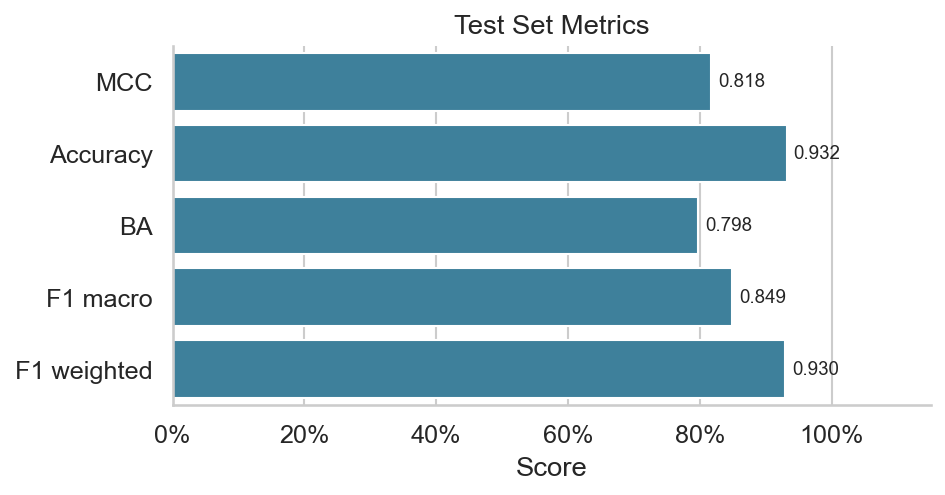

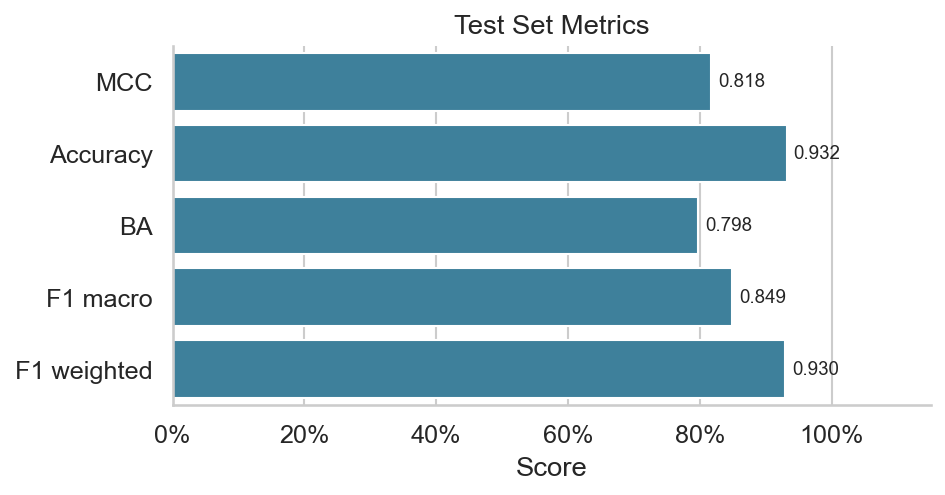

In [21]:
# Evaluation metrics bar chart
# binary eval → flat dict; multiclass eval → nested, scalars in "overall_metrics"
_eval = model_result["test_evaluation"]
_scalars = _eval.get("overall_metrics", _eval)
plot_metric_bar(_scalars, title="Test Set Metrics")
#plt.show()

## 9c. Export predictions to CSV (MCP tool)

`export_predictions` writes a per-sample CSV with (where available):

| Column | Description |
|---|---|
| `cid` | Compound ID (from the original dataset, if present) |
| `smiles` | SMILES string (if present) |
| `true_label` | Ground-truth label |
| `predicted_label` | Model prediction |
| `prob_class_0`, `prob_class_1` | Class probabilities (classification only) |

For regression tasks `predicted_label` is replaced by `predicted_value`. A `.pkl` metrics file is saved alongside the CSV. Both land in `<session>/results/`.

In [18]:
export_result = export_predictions(
    model_path=model_result["model_path"],
    split_file_path=data_splits["saved_to"],
    task="classification",
    split="test",          # default
)
export_result

{'csv_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260424_173702_aead5d\\results\\trained_model_RFC_test_predictions.csv',
 'metrics_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260424_173702_aead5d\\results\\trained_model_RFC_test_metrics.pkl',
 'metrics': {'target': None,
  'algorithm': 'trained_model_RFC',
  'overall_metrics': {'MCC': 0.8176044457544901,
   'Accuracy': 0.9322916666666666,
   'BA': 0.7976284009893787,
   'F1 macro': 0.8490413794153007,
   'F1 weighted': 0.9295263253511696},
  'per_class_metrics': {'Class_0': {'Precision': 0.9313725490196079,
    'Recall': 0.9827586206896551,
    'F1': 0.9563758389261745,
    'Support': 290},
   'Class_1': {'Precision': 0.9411764705882353,
    'Recall': 0.810126582278481,
    'F1': 0.8707482993197279,
    'Support': 79},
   'Cla